# Assignment 3: Autonomous Driving (Part 2)


In this assignment, you will continue from **Assignment 2: Autonomous Driving (Part 1)**. You should already have collected a Car Racing dataset, saved it as `.npz`, written a `metadata.json` action mapping, and implemented a PyTorch-compatible data loading pipeline.

The goal of this assignment is therefore **not** to collect or prepare the dataset again. Instead, you will use your existing dataset pipeline to train a convolutional neural network (CNN) controller, compare several training settings, and finally run the trained controller in the Gymnasium simulator.

The learning problem is treated as **imitation learning**: the model receives an image observation from the Car Racing environment and predicts the discrete action demonstrated by the human driver during data collection.

**Note:** All scripts must be executable on **any** machine with the required libraries installed. Assignment solutions may be submitted either as Jupyter notebooks or `.py` files. Visual results may be submitted as part of the notebook, a PDF, or image files. When submitting multiple files, create a zip archive that contains all submissions.


## Task 1: Reuse the Dataset Pipeline From Assignment 2

In Assignment 2, you generated the dataset and implemented the PyTorch data pipeline. In this task, you will connect that existing work to the training experiments below.

Do **not** repeat the data collection task here. Adapt the scaffold below using your **finished Assignment 2 code**.

Use one fixed split for all experiments:

- 60% consecutive training samples
- 20% consecutive validation samples
- 20% consecutive test samples

The dataset must not be shuffled before splitting. The training loader may shuffle mini-batches after the split has been created.

### What you need to do

1. Load the `.npz` dataset and `metadata.json` generated in Assignment 2.
2. Create train, validation, and test loaders using the fixed consecutive split.
3. Print the split sizes and inspect one mini-batch shape.
4. Keep this same split for all following experiments.

**Task Output:** Fixed split indices and train/validation/test data loaders.

In [ ]:
# Import Versions:
import sys
import numpy as np
import pandas as pd
import gymnasium as gym

import matplotlib
import torch

import PIL

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Gymnasium:", gym.__version__)
print("Matplotlib:", matplotlib.__version__)
print("PyTorch:", torch.__version__)
print("PIL:", PIL.__version__)

Python: 3.11.13 (main, Jun  5 2025, 13:12:00) [GCC 11.2.0]
NumPy: 2.3.4
Pandas: 3.0.2
Gymnasium: 1.3.0
Matplotlib: 3.10.3
PyTorch: 2.11.0+cu126
PIL: 12.0.0


Train samples: 3000
Validation samples: 1000
Test samples: 1000
torch.Size([64, 3, 96, 96])
torch.Size([64, 5])


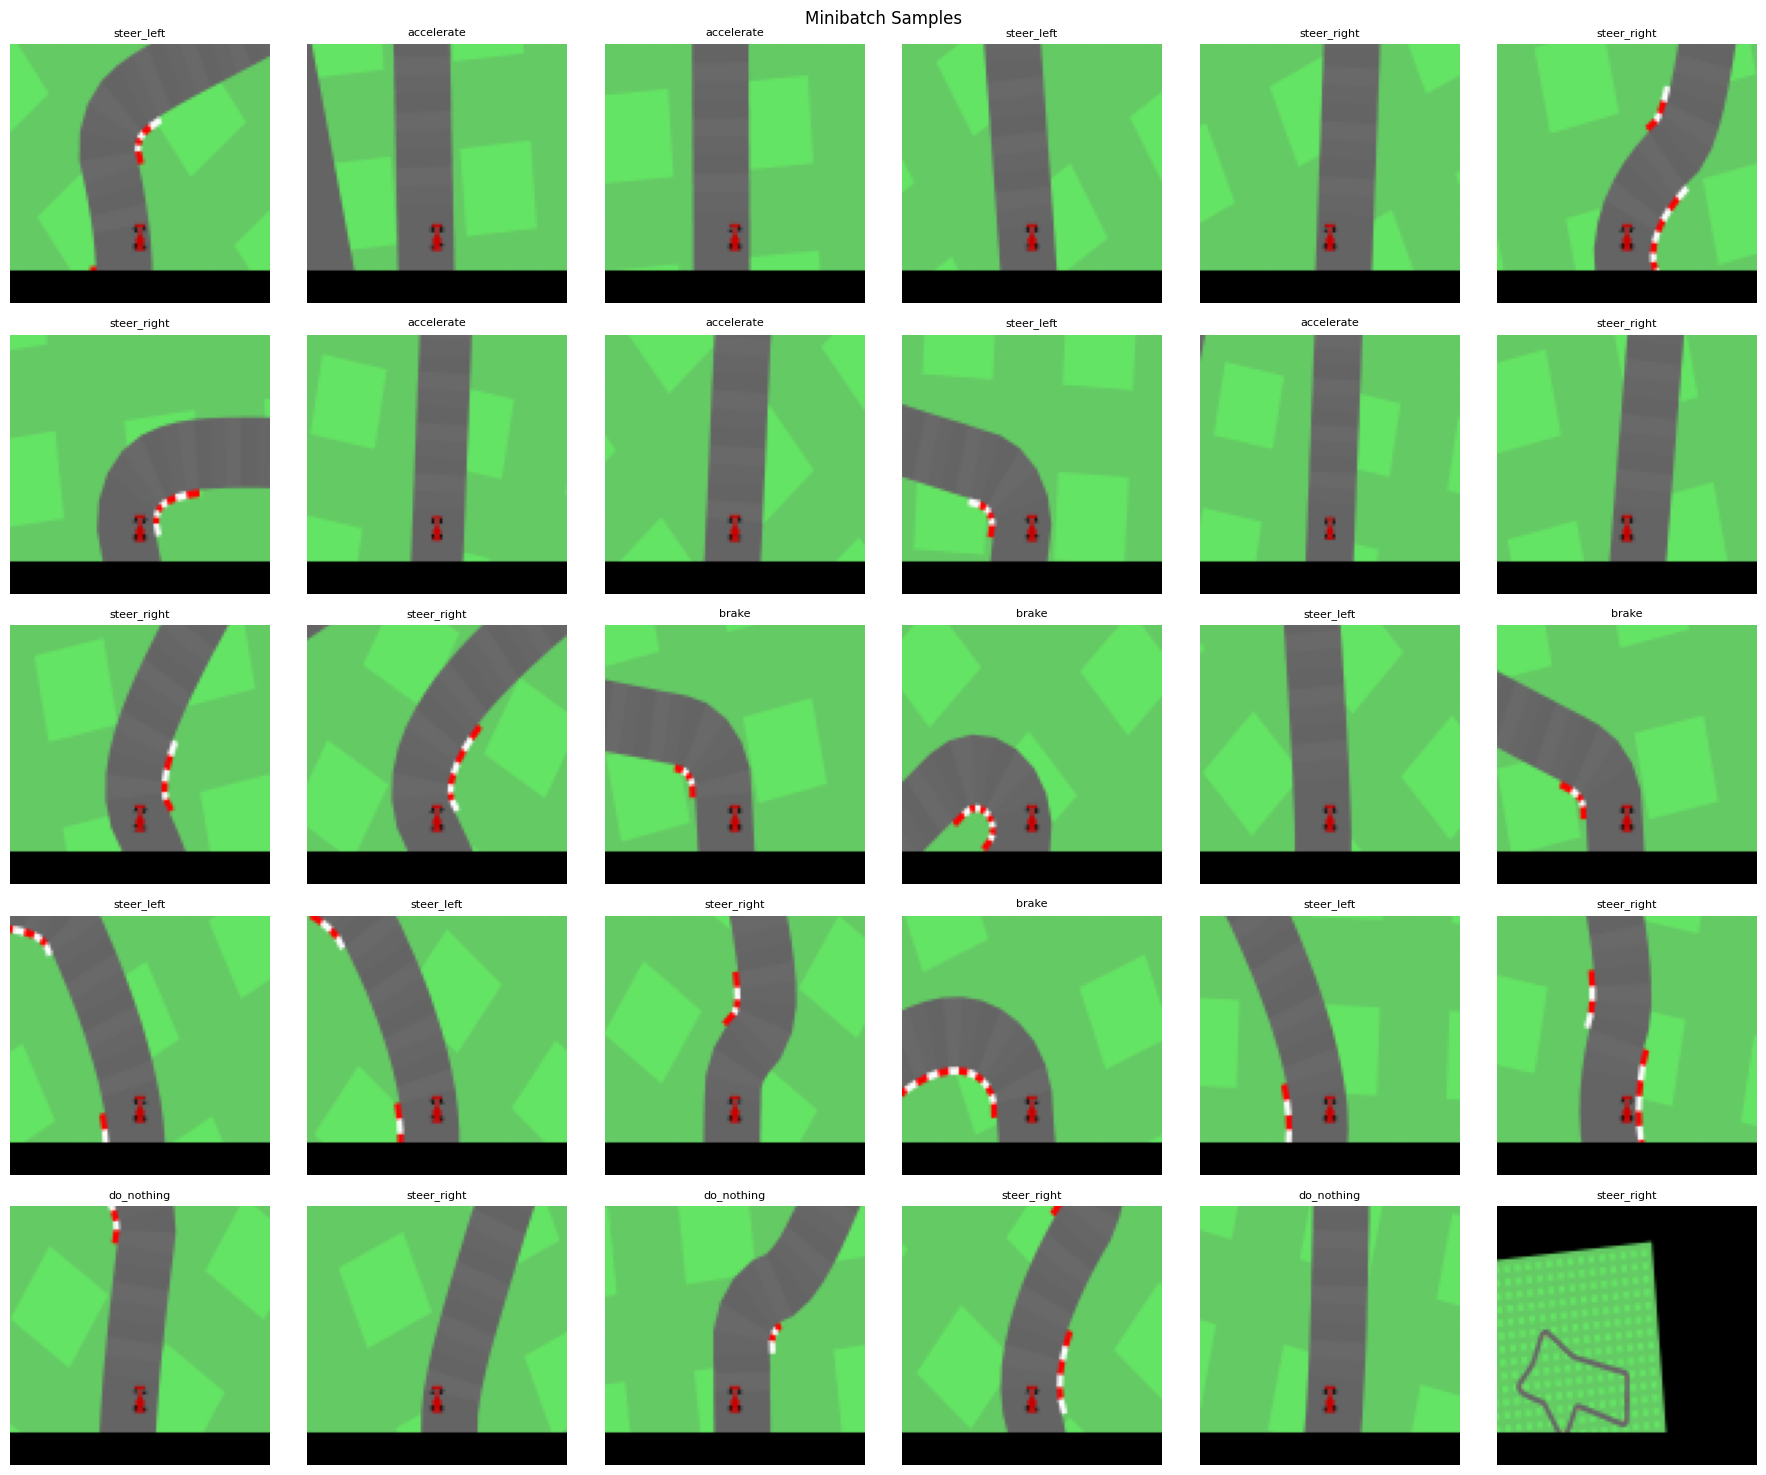

In [ ]:
from pathlib import Path
import json
import random
import copy

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

BATCH_SIZE = 64
NUM_CLASSES = 5
MAX_EPOCHS = 60

DATA_DIR = Path("../Assignment_2/data") 
DATASET_PATH = DATA_DIR / "dataset.npz"
METADATA_PATH = DATA_DIR / "metadata.json"

# TODO: load images, labels, and metadata from the files generated in Assignment 2
data = np.load(DATASET_PATH)
images = data["images"]
labels = data["labels"]
with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

if "action_mapping" in metadata:
    action_mapping = metadata["action_mapping"]

# TODO: define or infer the action indices needed for label updates during augmentation
LEFT_ACTION = action_mapping["2"]
RIGHT_ACTION = action_mapping["1"]

# TODO: create a consecutive 60/20/20 split
# TODO [optional] split long recordings into shorter clips to increase the number of samples
n = len(images)
indices = np.arange(n)

np.random.seed(SEED)
np.random.shuffle(indices)

n_train = int(0.6 * n)
n_val = int(0.2 * n)

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train + n_val]
test_indices = indices[n_train + n_val:]

print(f"Train samples: {len(train_indices)}")
print(f"Validation samples: {len(val_indices)}")
print(f"Test samples: {len(test_indices)}")

# TODO: use the dataset class from Assignment 2
class CarRacingDataset(Dataset):
    def __init__(
        self,
        data_dir,
        indices,
        horizontal_flip=False,
        flip_prob=0.5,
        gaussian_noise=False,
        noise_prob=0.5,
        noise_std=0.03,
        brown_road=False,
        brown_prob=0.5,
        blackout_hud=False,
    ):
        path = Path(data_dir)

        # Allows "dataset.npz" and Folder
        if path.is_dir(): # For directories
            data_path = path / "dataset.npz"
            meta_path = path / "metadata.json"
        else: # For explicit link to data
            data_path = path 
            meta_path = path.with_name("metadata.json")

        with np.load(data_path) as data:
            self.images = data["images"].copy() # Load images without changing dataset
            self.labels = data["labels"].astype(np.float32).copy() # Preperation for PyTorch

        self.indices = indices
        self.horizontal_flip = horizontal_flip
        self.flip_prob = flip_prob
        self.gaussian_noise = gaussian_noise
        self.noise_prob = noise_prob
        self.noise_std = noise_std
        self.brown_road = brown_road
        self.brown_prob = brown_prob

        self.blackout_hud = blackout_hud # Hide HUD so that model doesn't learn from HUD

        # Load action names from metadata.json
        if meta_path.exists():
            with open(meta_path, "r", encoding="utf-8") as f: # Read mode
                metadata = json.load(f)

            action_mapping = metadata.get("action_mapping", None)
            if isinstance(action_mapping, dict):
                parsed_names = []
                for i in range(5):
                    if str(i) in action_mapping:
                        parsed_names.append(action_mapping[str(i)]) # json saves indices/keys as string
                    elif i in action_mapping: # If no keys can be found
                        parsed_names.append(action_mapping[i])
                    else:
                        print("Error loading Action names from metadata.json")
                self.action_names = parsed_names

    def __len__(self):
        return len(self.indices)
    
    @staticmethod
    def _flip_label_left_right(label): # Needed wenn image will be flipped horizontally
        """
        Change one hot labels for:
        1 = steer_left
        2 = steer_right
        """
        label = label.copy()
        label[[1, 2]] = label[[2, 1]]
        return label
    
    @staticmethod
    def _change_road_to_brown(image):
        """
        Simple heuristics:
        Gray Street pixels will be colored in brown
        """
        img = image.astype(np.float32).copy() # Change to float32 to avoid overflow

        r = img[..., 0]
        g = img[..., 1]
        b = img[..., 2]

        # Gray pixels: Channels similiar and mean intensity
        gray_mask = (
            (np.abs(r - g) < 15)
            & (np.abs(g - b) < 15)
            & (r > 60)
            & (r < 200)
        )

        # Calculate mean brightness of pixels
        brightness = img.mean(axis=-1, keepdims=True) / 255.0
        brown_base = np.array([150.0, 100.0, 60.0], dtype=np.float32).reshape(
            1, 1, 3
        )
        #Apply brown colour without changing brightness of pixels
        brown_img = np.clip((0.45 + 0.55 * brightness) * brown_base, 0, 255)

        img[gray_mask] = brown_img[gray_mask]
        return img.astype(np.uint8)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        image = self.images[real_idx].copy()
        label = self.labels[real_idx].copy()

        # Hide HUD
        if self.blackout_hud:
            image[-10:, :, :] = 0

        # 1) Horizontal flip
        if self.horizontal_flip and np.random.rand() < self.flip_prob:
            image = np.ascontiguousarray(np.fliplr(image)) # NumPy.FlipLeftRight(image), np.ascontiguousarray preserves array from changes
            label = self._flip_label_left_right(label) # Flip label 

        # 2) Change street color
        if self.brown_road and np.random.rand() < self.brown_prob:
            image = self._change_road_to_brown(image)

        # Change to float float [0, 1] 
        image = image.astype(np.float32) / 255.0

        # 3) Gaussian noise
        if self.gaussian_noise and np.random.rand() < self.noise_prob:
            noise = np.random.normal(
                loc=0.0,
                scale=self.noise_std,
                size=image.shape,
            ).astype(np.float32)
            image = np.clip(image + noise, 0.0, 1.0)

        # HxWxC -> CxHxW for PyTorch
        image = torch.from_numpy(np.transpose(image, (2, 0, 1))).float()
        label = torch.from_numpy(label).float()

        return image, label


# TODO: create train/validation/test datasets and data loaders
train_dataset =  CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=train_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)


val_dataset = CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=val_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)

test_dataset = CarRacingDataset( # Dataset with augmentation
    data_dir=DATA_DIR,
    indices=test_indices,
    horizontal_flip=False,
    flip_prob=0.5,
    gaussian_noise=False,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=False,
    brown_prob=0.5,
    blackout_hud=True,
)

train_loader  = DataLoader( # Dataloader
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader( # Dataloader
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader( # Dataloader
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# TODO: inspect one mini-batch
batch_images, batch_labels = next(iter(train_loader))

print(batch_images.shape)
print(batch_labels.shape)

def visualize_samples(dataset, n=30, title="Minibatch Samples"):
    n = min(n, len(dataset))
    cols = 6
    rows = int(np.ceil(n / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i in range(n):
        image, label = dataset[i]
        image_np = image.permute(1, 2, 0).numpy()
        action_idx = int(torch.argmax(label).item())
        action_name = dataset.action_names[action_idx]

        axes[i].imshow(image_np)
        axes[i].set_title(action_name, fontsize=8)
        axes[i].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

visualize_samples(dataset=train_dataset)



## Task 2: Define a CNN Driving Model

In this task, you will define a convolutional neural network that predicts the driving action from an input frame.

You may choose the exact architecture, but your model must include:

- at least **2 convolutional layers**,
- at least **1 linear layer**,
- ReLU activations or another clearly justified non-linearity,
- an output layer with **5 logits**, one for each action class.

Use `torch.nn.CrossEntropyLoss` during training. Do not apply `softmax` inside the model when using `CrossEntropyLoss`, because the loss function expects raw logits.

### What you need to do

1. Implement the CNN model.
2. Verify that one mini-batch passes through the model.
3. Print the output tensor shape and the number of trainable parameters.

**Task Output:** A PyTorch CNN model for Car Racing action classification.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

class CarRacingCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=5):
        super().__init__()

        # TODO: design your CNN architecture
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=5, stride=2, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x



# TODO: instantiate the model and verify that one mini-batch passes through it
model = CarRacingCNN(in_channels=3, num_classes=5).to(device)

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

logits = model(images)

print("Output shape:", logits.shape)
print("Trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


Using device: cuda
Output shape: torch.Size([64, 5])
Trainable parameters: 103365


## Task 3: Train the Baseline Model

In this task, you will train the CNN on the fixed split from Task 1. This is the baseline experiment, so no augmentation should be enabled.

Use early stopping with:

- `min_delta = 0.0`
- `patience = 3`

Track the loss and accuracy for the training, validation, and test subsets.\
The test set should only be used for evaluation, not for choosing the best model or tuning hyperparameters.

### What you need to do

1. Implement one training epoch.
2. Implement evaluation without gradient computation.
3. Implement early stopping based on validation loss.
4. Save the model parameters with the best validation loss.
5. Plot loss and accuracy over time.
6. Report optimizer, learning rate, batch size, number of epochs run, and final test performance.

**Task Output:** Training curves and test-set loss/accuracy for the baseline model.


Using device: cuda
Epoch 01/60 | train loss 1.6114, train acc 0.1967 | val loss 1.6109, val acc 0.1940
Epoch 02/60 | train loss 1.6085, train acc 0.2107 | val loss 1.6014, val acc 0.2980
Epoch 03/60 | train loss 1.5702, train acc 0.3047 | val loss 1.4844, val acc 0.3650
Epoch 04/60 | train loss 1.4102, train acc 0.3677 | val loss 1.4221, val acc 0.3830
Epoch 05/60 | train loss 1.3732, train acc 0.4090 | val loss 1.3550, val acc 0.4060
Epoch 06/60 | train loss 1.3001, train acc 0.4433 | val loss 1.3243, val acc 0.4040
Epoch 07/60 | train loss 1.2318, train acc 0.4763 | val loss 1.2252, val acc 0.4610
Epoch 08/60 | train loss 1.1721, train acc 0.4973 | val loss 1.1824, val acc 0.4750
Epoch 09/60 | train loss 1.1565, train acc 0.5013 | val loss 1.1555, val acc 0.4840
Epoch 10/60 | train loss 1.0838, train acc 0.5313 | val loss 1.1483, val acc 0.4960
Epoch 11/60 | train loss 1.0473, train acc 0.5367 | val loss 1.0937, val acc 0.5210
Epoch 12/60 | train loss 1.0479, train acc 0.5433 | val l

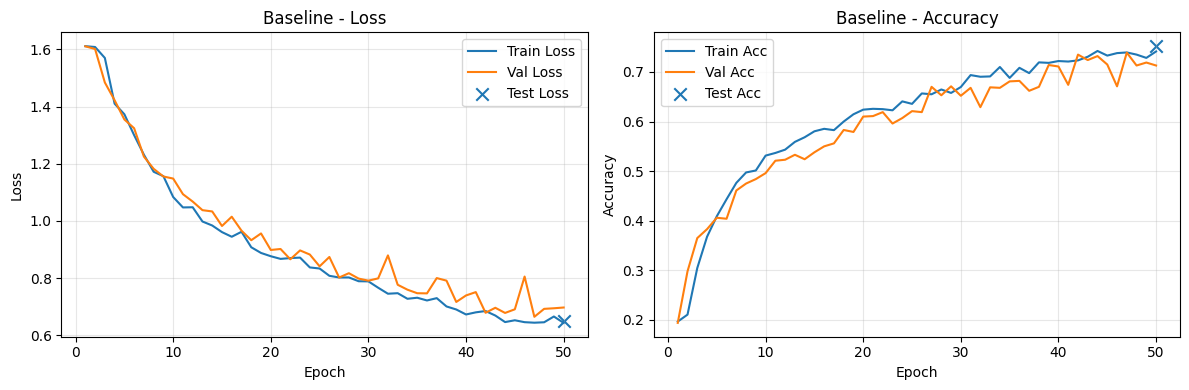

Baseline test loss / accuracy: (0.6501209311485291, 0.752)
Optimizer: Adam
Learning rate: 0.001
Batch size: 64
Epochs run: 50


In [6]:
from copy import deepcopy

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if labels.ndim == 2:
            labels = labels.argmax(dim=1)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if labels.ndim == 2:
            labels = labels.argmax(dim=1)


        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = images.size(0)
        running_loss += loss.item() * batch_size

        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += batch_size

    avg_loss = running_loss / total
    avg_acc = correct / total

    return avg_loss, avg_acc


def fit_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    device,
    max_epochs=MAX_EPOCHS,
    min_delta=0.0,
    patience=3,
):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
    }

    best_val_loss = float("inf")
    best_state = deepcopy(model.state_dict())
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device
        )
        val_loss, val_acc = evaluate(
            model, val_loader, criterion, device
        )

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d}/{max_epochs} | "
            f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f}, val acc {val_acc:.4f}"
        )

        # Early stopping based on validation loss
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            print(
                f"Early stopping triggered after {epoch + 1} epochs. "
                f"Best val loss: {best_val_loss:.4f}"
            )
            break

    # Load best model
    model.load_state_dict(best_state)

    # Final test evaluation only once
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    return model, history, (test_loss, test_acc)


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")

    # Optional: last test point as marker only
    if "test_loss" in history:
        axes[0].scatter(
            [len(epochs)],
            [history["test_loss"]],
            label="Test Loss",
            marker="x",
            s=80,
        )

    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")

    if "test_acc" in history:
        axes[1].scatter(
            [len(epochs)],
            [history["test_acc"]],
            label="Test Acc",
            marker="x",
            s=80,
        )

    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# TODO: train the baseline model without augmentation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

baseline_model = CarRacingCNN(in_channels=3, num_classes=5).to(device)

criterion = nn.CrossEntropyLoss() #log(5) ca 1.61
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=1e-3)

baseline_model, baseline_history, baseline_test = fit_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    max_epochs=60,
    min_delta=0.0,
    patience=3,
)

baseline_history["test_loss"] = baseline_test[0]
baseline_history["test_acc"] = baseline_test[1]

plot_history(baseline_history, "Baseline")
print("Baseline test loss / accuracy:", baseline_test)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Batch size:", train_loader.batch_size)
print("Epochs run:", len(baseline_history["train_loss"]))

## Task 4: Train With the Assignment 2 Augmentation Pipeline

In Assignment 2, you implemented optional data augmentation in the data loading pipeline.\
In this task, you will use that existing augmentation functionality as a training experiment.

Do **not** create augmented copies of the dataset on disk. Augmentations must be applied dynamically while loading mini-batches.\
Use the same train/validation/test split as in Task 1 and apply augmentation only to the training subset.

If your Assignment 2 augmentation code includes horizontal flipping, remember that steering labels must be updated when an image is flipped.

### What you need to do

1. Enable the augmentation options from your Assignment 2 data loader for the training subset.
2. Keep validation and test loaders unaugmented.
3. Train a new model with the same model architecture and training settings as the baseline.
4. Compare loss and accuracy with and without augmentation in the same figure.

**Task Output:** Augmented training curves, test-set loss/accuracy, and comparison plot.


Epoch 01/60 | train loss 1.6102, train acc 0.2047 | val loss 1.6110, val acc 0.1880
Epoch 02/60 | train loss 1.6098, train acc 0.1987 | val loss 1.6058, val acc 0.2160
Epoch 03/60 | train loss 1.6017, train acc 0.2387 | val loss 1.5954, val acc 0.2550
Epoch 04/60 | train loss 1.5143, train acc 0.3273 | val loss 1.4545, val acc 0.3340
Epoch 05/60 | train loss 1.3871, train acc 0.3880 | val loss 1.3738, val acc 0.4250
Epoch 06/60 | train loss 1.3125, train acc 0.4390 | val loss 1.3640, val acc 0.4520
Epoch 07/60 | train loss 1.2083, train acc 0.4603 | val loss 1.1574, val acc 0.4810
Epoch 08/60 | train loss 1.1215, train acc 0.4887 | val loss 1.1344, val acc 0.4590
Epoch 09/60 | train loss 1.0781, train acc 0.5043 | val loss 1.0980, val acc 0.4780
Epoch 10/60 | train loss 1.0641, train acc 0.5137 | val loss 1.0913, val acc 0.5020
Epoch 11/60 | train loss 1.0454, train acc 0.5157 | val loss 1.1365, val acc 0.4790
Epoch 12/60 | train loss 1.0258, train acc 0.5297 | val loss 1.0321, val acc

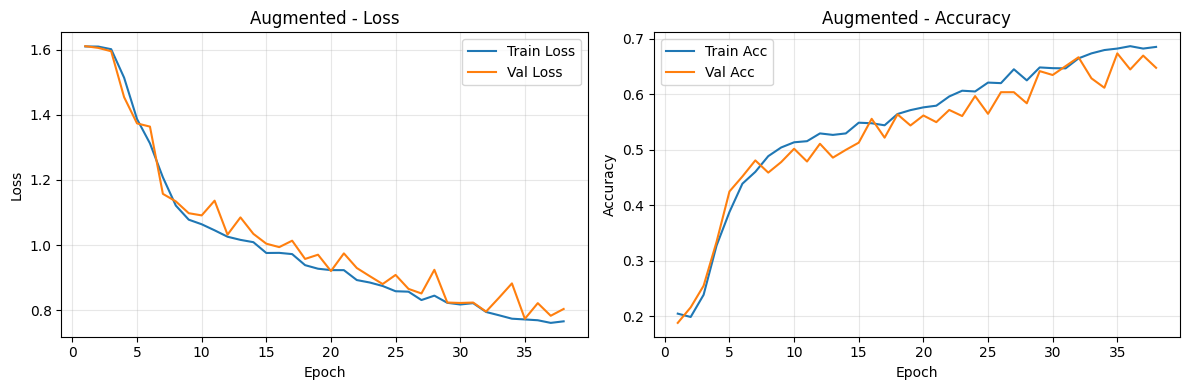

Augmented test loss / accuracy: (0.7402263860702515, 0.706)


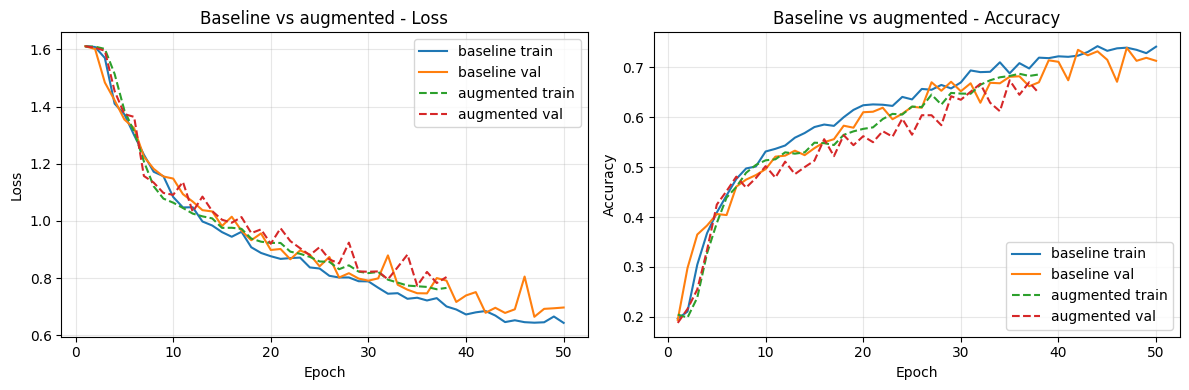

In [ ]:
# TODO: create an augmented training dataset using dynamic augmentation only for training
augmented_train_dataset = CarRacingDataset(
    data_dir=DATA_DIR,
    indices=train_indices,
    horizontal_flip=True,
    flip_prob=0.5,
    gaussian_noise=True,
    noise_prob=0.5,
    noise_std=0.03,
    brown_road=True,
    brown_prob=0.5,
    blackout_hud=True,
)

augmented_val_dataset =  CarRacingDataset(
    data_dir=DATA_DIR,
    indices=val_indices,
    horizontal_flip=False,
    gaussian_noise=False,
    brown_road=False,
    blackout_hud=True,
)

augmented_test_dataset =  CarRacingDataset(
    data_dir=DATA_DIR,
    indices=test_indices,
    horizontal_flip=False,
    gaussian_noise=False,
    brown_road=False,
    blackout_hud=True,
)

augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

augmented_val_loader = DataLoader(
    augmented_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

augmented_test_loader = DataLoader(
    augmented_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

# TODO: train a second model with augmentation enabled
augmented_model = CarRacingCNN(in_channels=3, num_classes=NUM_CLASSES).to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(augmented_model.parameters(), lr=1e-3)

augmented_model, augmented_history, augmented_test = fit_model(
    model=augmented_model,
    train_loader=augmented_train_loader,
    val_loader=augmented_val_loader,
    test_loader=augmented_test_loader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    max_epochs=MAX_EPOCHS,
    min_delta=0.0,
    patience=3,
)

plot_history(augmented_history, "Augmented")
print("Augmented test loss / accuracy:", augmented_test)


def plot_experiment_comparison(history_a, history_b, label_a, label_b, title):
    # TODO: compare loss and accuracy curves for two experiments
    epochs_a = range(1, len(history_a["train_loss"]) + 1)
    epochs_b = range(1, len(history_b["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Loss plot
    axes[0].plot(
        epochs_a,
        history_a["train_loss"],
        label=f"{label_a} train",
    )
    axes[0].plot(
        epochs_a,
        history_a["val_loss"],
        label=f"{label_a} val",
    )
    axes[0].plot(
        epochs_b,
        history_b["train_loss"],
        label=f"{label_b} train",
        linestyle="--",
    )
    axes[0].plot(
        epochs_b,
        history_b["val_loss"],
        label=f"{label_b} val",
        linestyle="--",
    )
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # Accuracy plot
    axes[1].plot(
        epochs_a,
        history_a["train_acc"],
        label=f"{label_a} train",
    )
    axes[1].plot(
        epochs_a,
        history_a["val_acc"],
        label=f"{label_a} val",
    )
    axes[1].plot(
        epochs_b,
        history_b["train_acc"],
        label=f"{label_b} train",
        linestyle="--",
    )
    axes[1].plot(
        epochs_b,
        history_b["val_acc"],
        label=f"{label_b} val",
        linestyle="--",
    )
    axes[1].set_title(f"{title} - Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_experiment_comparison(baseline_history, augmented_history, "baseline", "augmented", "Baseline vs augmented")


## Task 5: Offline Error Analysis

Before running the trained controllers in simulation, analyze how well each model predicts each action class.

Overall accuracy can be misleading if the dataset is imbalanced. In this task, evaluate whether the models are learning all driving actions or mainly predicting the most frequent class.

### What you need to do

1. Plot the action distribution for the train, validation, and test splits, in a single bar plot.
2. Compute a majority-class baseline accuracy on the test set.
3. Compute and display a confusion matrix for the baseline and augmented models.
4. Report per-class accuracy, precision, recall, or F1-score.
5. Briefly discuss which actions are most often confused.

**Task Output:** Action distribution plots, majority-class baseline, confusion matrices, and per-class metrics.

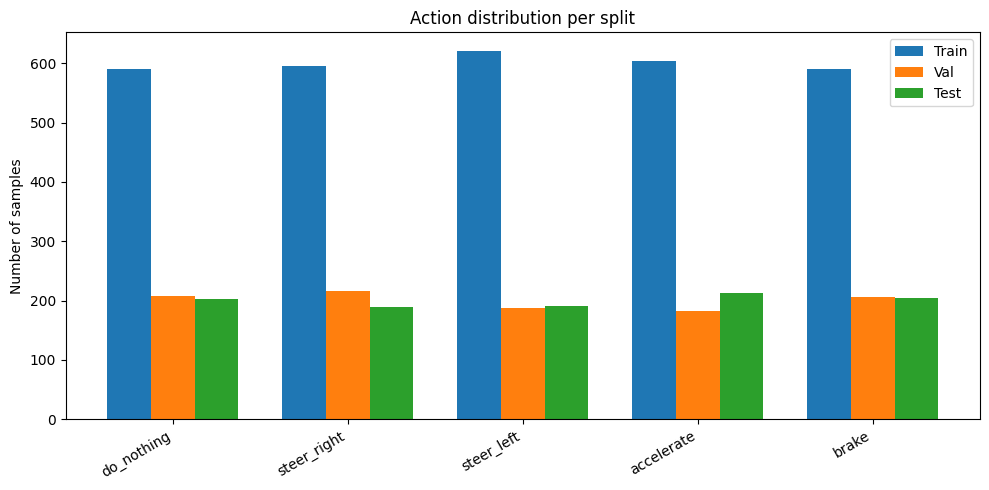

Majority class: steer_left
Majority-class test accuracy: 0.191

Baseline Model
--------------
Accuracy: 0.7520


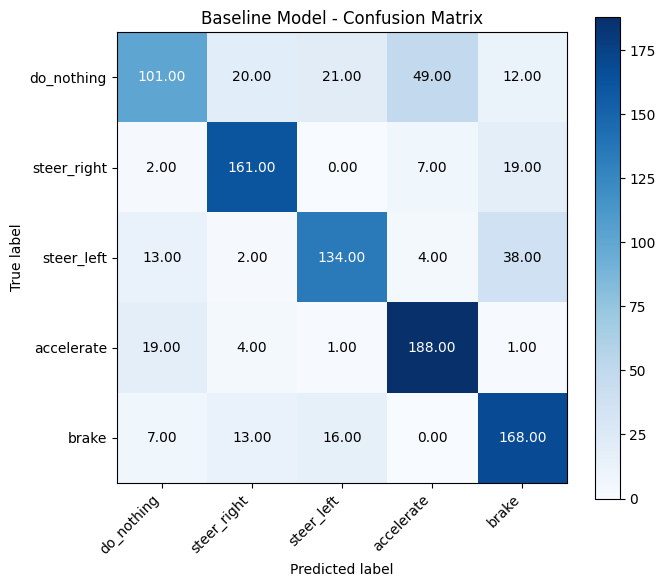

Class            Precision     Recall         F1    Support
------------------------------------------------------------
do_nothing          0.7113     0.4975     0.5855        203
steer_right         0.8050     0.8519     0.8278        189
steer_left          0.7791     0.7016     0.7383        191
accelerate          0.7581     0.8826     0.8156        213
brake               0.7059     0.8235     0.7602        204

Augmented Model
---------------
Accuracy: 0.7060


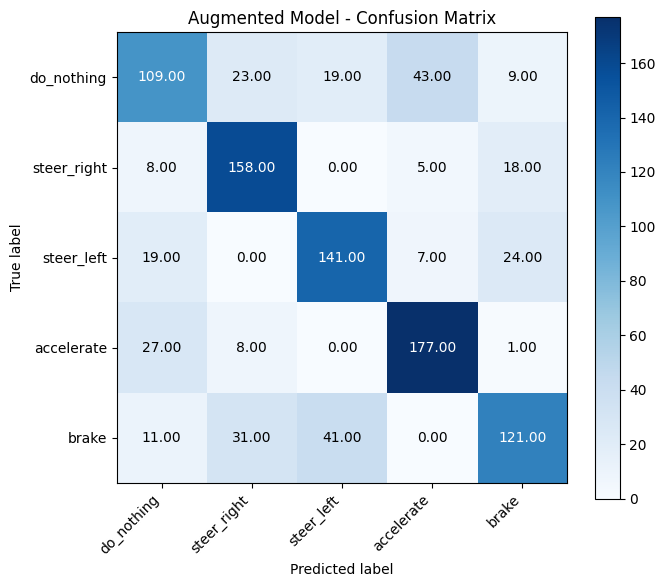

Class            Precision     Recall         F1    Support
------------------------------------------------------------
do_nothing          0.6264     0.5369     0.5782        203
steer_right         0.7182     0.8360     0.7726        189
steer_left          0.7015     0.7382     0.7194        191
accelerate          0.7629     0.8310     0.7955        213
brake               0.6994     0.5931     0.6419        204


In [10]:
# TODO: Visualize and compute model metrics
class_names = [action_mapping[str(i)] for i in range(NUM_CLASSES)]

def labels_to_class_indices(labels):
    if torch.is_tensor(labels):
        if labels.ndim == 2:
            return labels.argmax(dim=1)
        return labels
    labels = np.asarray(labels)
    if labels.ndim == 2:
        return labels.argmax(axis=1)
    return labels


def collect_true_labels(loader):
    all_labels = []
    for _, labels in loader:
        labels = labels_to_class_indices(labels)
        all_labels.append(labels.cpu().numpy())
    return np.concatenate(all_labels, axis=0)


def collect_predictions(model, loader, device):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1)
            all_preds.append(preds.cpu().numpy())

    return np.concatenate(all_preds, axis=0)


def plot_action_distribution(train_loader, val_loader, test_loader, class_names):
    y_train = collect_true_labels(train_loader)
    y_val = collect_true_labels(val_loader)
    y_test = collect_true_labels(test_loader)

    n_classes = len(class_names)
    train_counts = np.bincount(y_train, minlength=n_classes)
    val_counts = np.bincount(y_val, minlength=n_classes)
    test_counts = np.bincount(y_test, minlength=n_classes)

    x = np.arange(n_classes)
    width = 0.25

    plt.figure(figsize=(10, 5))
    plt.bar(x - width, train_counts, width=width, label="Train")
    plt.bar(x, val_counts, width=width, label="Val")
    plt.bar(x + width, test_counts, width=width, label="Test")

    plt.xticks(x, class_names, rotation=30, ha="right")
    plt.ylabel("Number of samples")
    plt.title("Action distribution per split")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return train_counts, val_counts, test_counts


def majority_class_baseline_accuracy(train_loader, test_loader):
    y_train = collect_true_labels(train_loader)
    y_test = collect_true_labels(test_loader)

    counts = np.bincount(y_train)
    majority_class = counts.argmax()
    test_acc = (y_test == majority_class).mean()

    return majority_class, test_acc

def compute_confusion_matrix(y_true, y_pred, n_classes):
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    return cm

def plot_confusion_matrix(cm, class_names, title, normalize=False):
    cm_plot = cm.astype(np.float32)

    if normalize:
        row_sums = cm_plot.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        cm_plot = cm_plot / row_sums

    plt.figure(figsize=(7, 6))
    im = plt.imshow(cm_plot, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar(im)

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, class_names)

    fmt = ".2f"
    thresh = cm_plot.max() / 2.0 if cm_plot.max() > 0 else 0.5

    for i in range(cm_plot.shape[0]):
        for j in range(cm_plot.shape[1]):
            plt.text(
                j,
                i,
                format(cm_plot[i, j], fmt),
                ha="center",
                va="center",
                color="white" if cm_plot[i, j] > thresh else "black",
            )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

def classification_metrics_from_cm(cm):
    n_classes = cm.shape[0]
    metrics = []

    for c in range(n_classes):
        tp = cm[c, c]
        fp = cm[:, c].sum() - tp
        fn = cm[c, :].sum() - tp

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = (
            2 * precision * recall / (precision + recall)
            if (precision + recall) > 0
            else 0.0
        )
        support = cm[c, :].sum()

        metrics.append((precision, recall, f1, support))

    return metrics


def print_classification_report(cm, class_names):
    metrics = classification_metrics_from_cm(cm)

    print(
        f"{'Class':<15} {'Precision':>10} {'Recall':>10} "
        f"{'F1':>10} {'Support':>10}"
    )
    print("-" * 60)

    for name, (precision, recall, f1, support) in zip(class_names, metrics):
        print(
            f"{name:<15} {precision:10.4f} {recall:10.4f} "
            f"{f1:10.4f} {support:10d}"
        )

    return metrics

def evaluate_model_offline(model, loader, device, class_names, title):
    y_true = collect_true_labels(loader)
    y_pred = collect_predictions(model, loader, device)

    acc = (y_true == y_pred).mean()
    print(f"\n{title}")
    print("-" * len(title))
    print(f"Accuracy: {acc:.4f}")

    cm = compute_confusion_matrix(y_true, y_pred, n_classes=len(class_names))
    plot_confusion_matrix(cm, class_names, f"{title} - Confusion Matrix")
    print_classification_report(cm, class_names)

    return y_true, y_pred, cm, acc

plot_action_distribution(train_loader, val_loader, test_loader, class_names)

majority_class, majority_test_acc = majority_class_baseline_accuracy(
    train_loader, test_loader
)
print("Majority class:", class_names[int(majority_class)])
print("Majority-class test accuracy:", majority_test_acc)

baseline_y_true, baseline_y_pred, baseline_cm, baseline_acc = (
    evaluate_model_offline(
        baseline_model,
        test_loader,
        device,
        class_names,
        "Baseline Model",
    )
)

aug_y_true, aug_y_pred, aug_cm, aug_acc = evaluate_model_offline(
    augmented_model,
    augmented_test_loader,
    device,
    class_names,
    "Augmented Model",
)

# TODO: add your written discussion in a markdown cell below

**Brief Discussion:**
The most confusing classes are do_nothing and accelerate. Without any details about the current velocity of the car, it is hard to predict whether the car should accelerate more or the current speed is enough for the current situation.
Also the class break is handicapping the potential of the model. The numbers of the training results are quite good, but in the simulation the model is struggeling to accelerate after breaking. This can be explained by the gathered dataset. In the dataset I tried to simulate that the car should break before the curve so that steering is easier, but I rarely had the situation that I accelerated after breaking (before the curve). That's why the car get's stuck in the simulation after breaking in front of a curve.
Without the class break the model would perform much better (IMO). 

## Task 6: Training Set Outlier Detection

Use the trained model to identify unusual or difficult training examples.

For each training sample, compute the model's cross-entropy loss and prediction confidence.\
Samples with high loss or low confidence may indicate mislabeled data, ambiguous driving situations, rare actions, or visually unusual states.

We define the model confidence as the highest softmax probability assigned to any action class $c$:

$
\text{confidence} = \max_c p_c
$

### What you need to do

1. Run the trained model on the training dataset without augmentation.
2. Select the top-10 highest-loss samples.
3. Visualize these samples together with:
   - true action
   - predicted action
   - model confidence
   - loss value
4. Briefly discuss whether these examples look like errors, rare situations, or useful hard examples.

**Task Output:** A visualization of the most difficult training samples and a short interpretation.

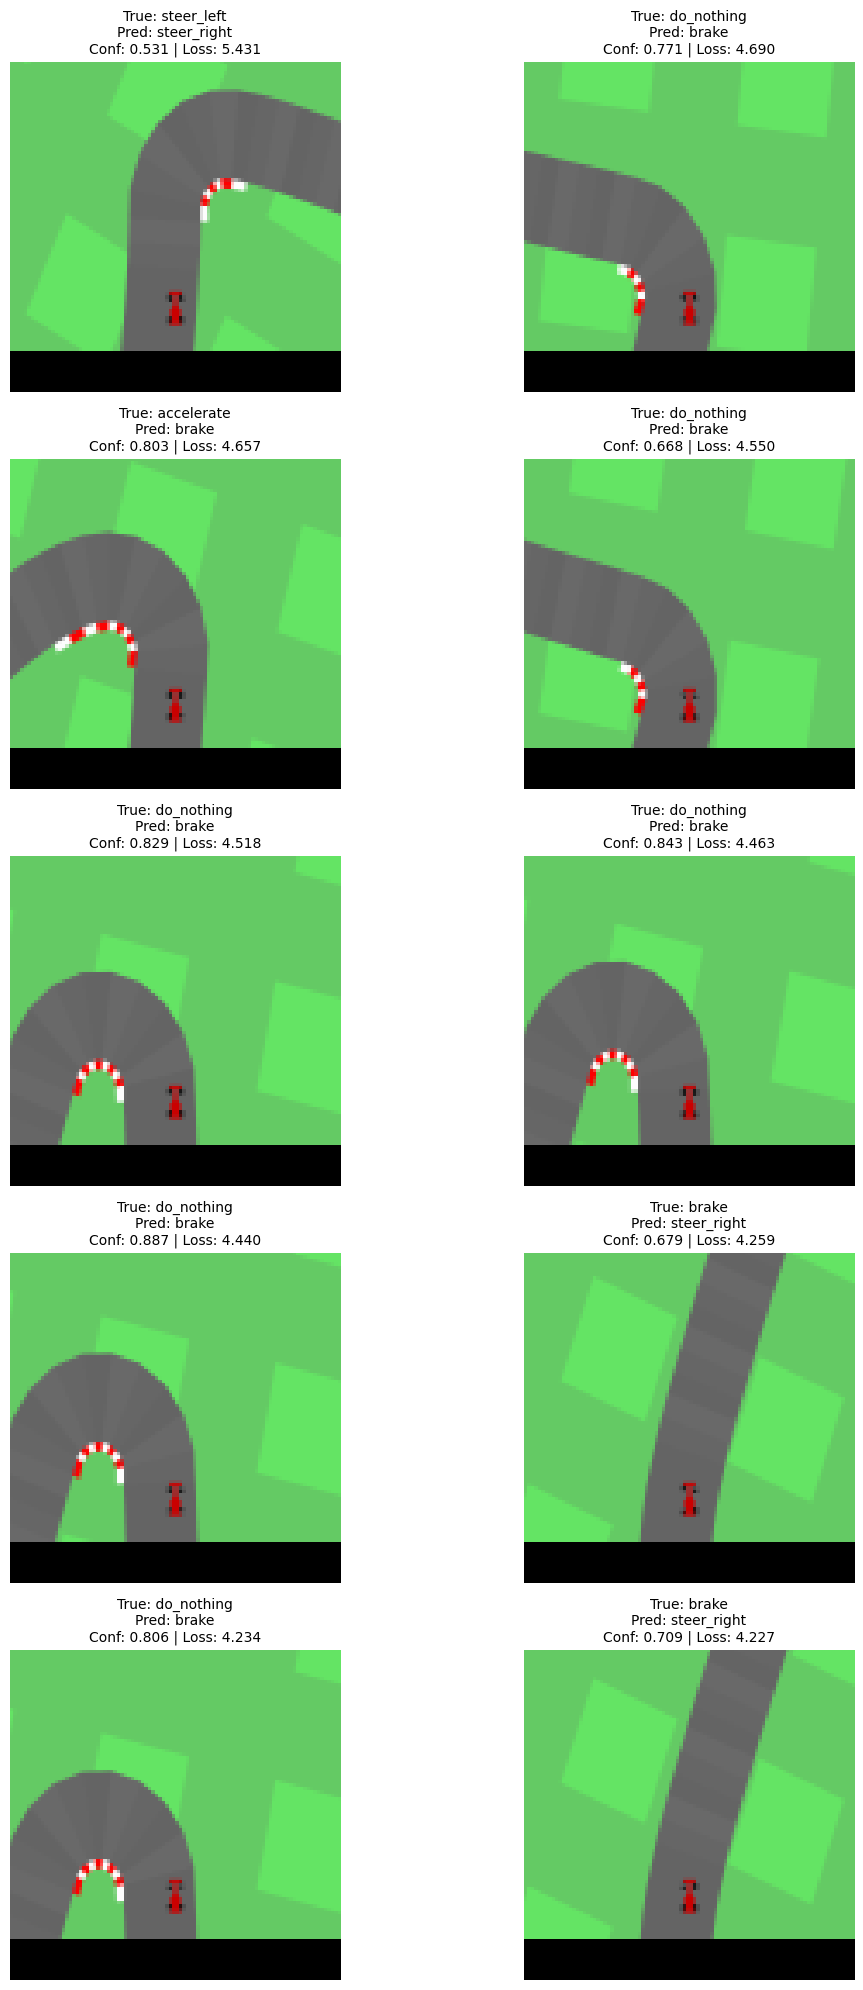

In [12]:
# TODO: find and visualize some failure cases for both models
def labels_to_class_indices(labels):
    if torch.is_tensor(labels):
        if labels.ndim == 2:
            return labels.argmax(dim=1)
        return labels
    labels = np.asarray(labels)
    if labels.ndim == 2:
        return labels.argmax(axis=1)
    return labels

def collect_training_outliers(model, loader, device):
    model.eval()
    criterion = nn.CrossEntropyLoss(reduction="none")

    all_images = []
    all_true = []
    all_pred = []
    all_conf = []
    all_loss = []

    with torch.no_grad():
        for images, labels in loader:
            labels = labels_to_class_indices(labels).long()

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            probs = torch.softmax(logits, dim=1)

            loss = criterion(logits, labels)
            conf, pred = probs.max(dim=1)

            all_images.append(images.cpu())
            all_true.append(labels.cpu())
            all_pred.append(pred.cpu())
            all_conf.append(conf.cpu())
            all_loss.append(loss.cpu())

    all_images = torch.cat(all_images, dim=0)
    all_true = torch.cat(all_true, dim=0)
    all_pred = torch.cat(all_pred, dim=0)
    all_conf = torch.cat(all_conf, dim=0)
    all_loss = torch.cat(all_loss, dim=0)

    return all_images, all_true, all_pred, all_conf, all_loss

def get_top_k_by_loss(images, y_true, y_pred, conf, loss, k=10):
    topk_idx = torch.topk(loss, k=k, largest=True).indices
    return {
        "images": images[topk_idx],
        "y_true": y_true[topk_idx],
        "y_pred": y_pred[topk_idx],
        "conf": conf[topk_idx],
        "loss": loss[topk_idx],
        "indices": topk_idx,
    }

def visualize_top_k_outliers(
    images,
    y_true,
    y_pred,
    conf,
    loss,
    class_names,
    k=10,
    mean=None,
    std=None,
):
    images = images[:k]
    y_true = y_true[:k]
    y_pred = y_pred[:k]
    conf = conf[:k]
    loss = loss[:k]

    n = len(images)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 4 * rows))

    for i in range(n):
        img = images[i]

        if img.shape[0] == 3:
            img_np = img.permute(1, 2, 0).numpy()
            img_np = np.clip(img_np, 0, 1)
        else:
            img_np = img.squeeze(0).numpy()

        ax = plt.subplot(rows, cols, i + 1)
        ax.imshow(img_np, cmap="gray" if img_np.ndim == 2 else None)
        ax.axis("off")

        true_name = class_names[int(y_true[i])]
        pred_name = class_names[int(y_pred[i])]

        ax.set_title(
            f"True: {true_name}\n"
            f"Pred: {pred_name}\n"
            f"Conf: {float(conf[i]):.3f} | Loss: {float(loss[i]):.3f}",
            fontsize=10,
        )

    plt.tight_layout()
    plt.show()

train_images, train_true, train_pred, train_conf, train_loss = collect_training_outliers(
    baseline_model,
    train_loader,
    device,
)

top10 = get_top_k_by_loss(
    train_images,
    train_true,
    train_pred,
    train_conf,
    train_loss,
    k=10,
)

visualize_top_k_outliers(
    top10["images"],
    top10["y_true"],
    top10["y_pred"],
    top10["conf"],
    top10["loss"],
    class_names,
    k=10,
)

# TODO: add your written interpretation in a markdown cell below

**Short Interpretation:** 
The images show that the model is capable of predicting the right action for the shown situation. But while gathering the dataset it can happen that wrong inputs are made. Hence the images are getting labeled with a label which isn't the best for the shown situation.
But the model is capable in deciding the right actions for the shown situations.

## Task 7: Run the Trained Controller in Simulation

In this task, you will use the trained CNN as a controller inside the Gymnasium Car Racing environment.\
At each time step, the model receives the current image observation and predicts one of the five discrete actions.

We want to initialize the simulation with three different seeds to observe the variance of our controller.

### What you need to do

Repeat for three different seeds:
1. Create `CarRacing-v3` with `continuous=False`.
2. Convert each simulator observation into a model input tensor.
3. Predict an action with the trained model.
4. Step the environment using the predicted action.
5. Run at least one complete episode or a fixed maximum number of steps for each trained policy.
6. Report the total reward for each policy.
7. Display a video that shows the baseline and augmented policies driving in simulation next to each other.

Remember that high offline accuracy does not always guarantee stable closed-loop driving.

**Task Output:** Inference code, and for three different seeds: total episode rewards & side-by-side comparison video.


In [ ]:
import gymnasium as gym
import imageio.v2 as imageio
from PIL import Image, ImageDraw, ImageFont

BLACKOUT_HUD = True

@torch.no_grad()
def predict_action(model, observation, device):
    # TODO: preprocess one simulator observation and predict one discrete action
    obs = observation.copy()

    # Muss zu deinem Training passen
    if BLACKOUT_HUD:
        obs[-10:, :, :] = 0

    # uint8 [0,255] -> float32 [0,1]
    obs = obs.astype(np.float32) / 255.0

    # HWC -> CHW
    x = torch.from_numpy(obs).permute(2, 0, 1).unsqueeze(0).to(device)

    model = model.to(device)
    model.eval()

    logits = model(x)
    action = logits.argmax(dim=1).item()

    return int(action)


def rollout_action(model_action, step, frame_deltas, warmup_steps=25, stuck_window=12, stuck_delta=0.001):
    # TODO: optionally add rollout-only warm-start or stuck-recovery logic
    return int(model_action)


def run_policy_rollout(model, name, seed=SEED, max_steps=1000):
    # TODO: create the CarRacing environment and run one closed-loop episode
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make("CarRacing-v3", continuous=False, render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    env.action_space.seed(seed)

    model = model.to(device)
    model.eval()

    frames = []
    total_reward = 0.0
    frame_deltas = []
    prev_frame = None

    for step in range(max_steps):
        frame = env.render()
        if frame is not None:
            frames.append(frame)

            if prev_frame is not None:
                delta = np.mean(
                    np.abs(frame.astype(np.float32) - prev_frame.astype(np.float32))
                ) / 255.0
                frame_deltas.append(delta)

            prev_frame = frame

        model_action = predict_action(model, obs, device)
        action = rollout_action(model_action, step, frame_deltas)

        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += float(reward)

        if terminated or truncated:
            frame = env.render()
            if frame is not None:
                frames.append(frame)
            break

    env.close()
    
    return {
        "name": name,
        "frames": frames,
        "reward": total_reward,
        "episode_length": len(frames),
    }


policies = [
    {"name": "baseline RGB", "model": baseline_model},
    {"name": "augmented RGB", "model": augmented_model},
]

def add_corner_label(
    frame,
    text,
    bg_color=(0, 0, 0),
    text_color=(255, 255, 255),
):
    img = Image.fromarray(frame)
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("DejaVuSans.ttf", 18)
    except Exception:
        font = ImageFont.load_default()

    x0, y0 = 8, 8
    pad_x, pad_y = 8, 5

    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    rect = [
        x0,
        y0,
        x0 + text_w + 2 * pad_x,
        y0 + text_h + 2 * pad_y,
    ]

    draw.rectangle(rect, fill=bg_color)
    draw.text((x0 + pad_x, y0 + pad_y), text, fill=text_color, font=font)

    return np.array(img)

def save_labeled_video(frames, out_path, label, bg_color, fps=30):
    labeled_frames = [
        add_corner_label(frame, label, bg_color=bg_color) for frame in frames
    ]

    with imageio.get_writer(
        str(out_path),
        fps=fps,
        codec="libx264",
        format="FFMPEG",
    ) as writer:
        for frame in labeled_frames:
            writer.append_data(np.asarray(frame))

def save_side_by_side_video(
    left_frames,
    right_frames,
    out_path,
    left_label="baseline",
    right_label="augmented",
    fps=30,
):
    n = min(len(left_frames), len(right_frames))
    combined_frames = []

    for i in range(n):
        left = left_frames[i]
        right = right_frames[i]

        # Optional gleiche Größe erzwingen
        if left.shape[:2] != right.shape[:2]:
            right = np.array(
                Image.fromarray(right).resize((left.shape[1], left.shape[0]))
            )

        # Labels einblenden
        left_annotated = add_corner_label(
            left,
            left_label,
            bg_color=(20, 80, 180),  # blau
        )
        right_annotated = add_corner_label(
            right,
            right_label,
            bg_color=(180, 120, 20),  # orange
        )

        combined = np.concatenate([left_annotated, right_annotated], axis=1)
        combined_frames.append(combined)

    with imageio.get_writer(
        str(out_path),
        fps=fps,
        codec="libx264",
        format="FFMPEG",
    ) as writer:
        for frame in combined_frames:
            writer.append_data(np.asarray(frame))

policies = [
    {"name": "baseline RGB", "model": baseline_model},
    {"name": "augmented RGB", "model": augmented_model},
]

seeds = [42, 43, 44]
output_dir = Path("rollout_outputs")
output_dir.mkdir(exist_ok=True, parents=True)

all_results = []

for seed in seeds:
    print(f"\n=== Seed {seed} ===")

    rollout_results = []

    for policy in policies:
        result = run_policy_rollout(
            model=policy["model"],
            name=policy["name"],
            seed=seed,
            max_steps=1000,
        )
        rollout_results.append(result)

        all_results.append(
            {
                "seed": seed,
                "policy": result["name"],
                "reward": result["reward"],
                "episode_length": result["episode_length"],
            }
        )

        print(
            f'{result["name"]}: reward={result["reward"]:.2f}, '
            f'length={result["episode_length"]}'
        )

        video_path = (
            output_dir / f'{policy["name"].replace(" ", "_")}_seed{seed}.mp4'
        )

        if "baseline" in policy["name"].lower():
            label = "baseline"
            bg_color = (20, 80, 180)
        else:
            label = "augmented"
            bg_color = (180, 120, 20)

        save_labeled_video(
            result["frames"],
            video_path,
            label=label,
            bg_color=bg_color,
        )
        print(f"Saved: {video_path}")

    # Side-by-side comparison
    baseline_result = rollout_results[0]
    augmented_result = rollout_results[1]

    side_by_side_path = output_dir / f"comparison_seed{seed}.mp4"
    save_side_by_side_video(
        left_frames=baseline_result["frames"],
        right_frames=augmented_result["frames"],
        out_path=side_by_side_path,
        left_label="baseline",
        right_label="augmented",
        fps=30,
    )
    print(f"Saved comparison: {side_by_side_path}")

for r in all_results:
    print(
        f"Seed={r['seed']} | Policy={r['policy']:<15} | "
        f"Reward={r['reward']:.2f} | Length={r['episode_length']}"
    )
    
# TODO: run both policies, save individual rollout videos, and save one side-by-side comparison video




=== Seed 42 ===
baseline RGB: reward=16.61, length=1001


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: rollout_outputs3/baseline_RGB_seed42.mp4
augmented RGB: reward=16.61, length=1001


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: rollout_outputs3/augmented_RGB_seed42.mp4
Saved comparison: rollout_outputs3/comparison_seed42.mp4

=== Seed 43 ===
baseline RGB: reward=-43.89, length=1001


...

Saved: rollout_outputs3/augmented_RGB_seed43.mp4
Saved comparison: rollout_outputs3/comparison_seed43.mp4

=== Seed 44 ===
baseline RGB: reward=126.36, length=1001


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: rollout_outputs3/baseline_RGB_seed44.mp4
augmented RGB: reward=258.17, length=1001


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (600, 400) to (608, 400) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Saved: rollout_outputs3/augmented_RGB_seed44.mp4
Saved comparison: rollout_outputs3/comparison_seed44.mp4
Seed=42 | Policy=baseline RGB    | Reward=16.61 | Length=1001
Seed=42 | Policy=augmented RGB   | Reward=16.61 | Length=1001
Seed=43 | Policy=baseline RGB    | Reward=-43.89 | Length=1001
Seed=43 | Policy=augmented RGB   | Reward=348.84 | Length=1001
Seed=44 | Policy=baseline RGB    | Reward=126.36 | Length=1001
Seed=44 | Policy=augmented RGB   | Reward=258.17 | Length=1001


## Task 8: Final Comparison and Discussion

Summarize your results across all experiments.

### What you need to report

1. Baseline RGB model test loss and accuracy.
2. Augmented RGB model test loss and accuracy.
3. Closed-loop simulator reward for each trained controller.
4. A short explanation of which model worked best and why.
5. A short discussion of limitations, for example class imbalance, correlated frames, distribution shift, or compounding errors during closed-loop driving.
6. A short explanation why training with augmentations might not provide the best performance in this case. 

**Task Output:** Final result table and concise written discussion.

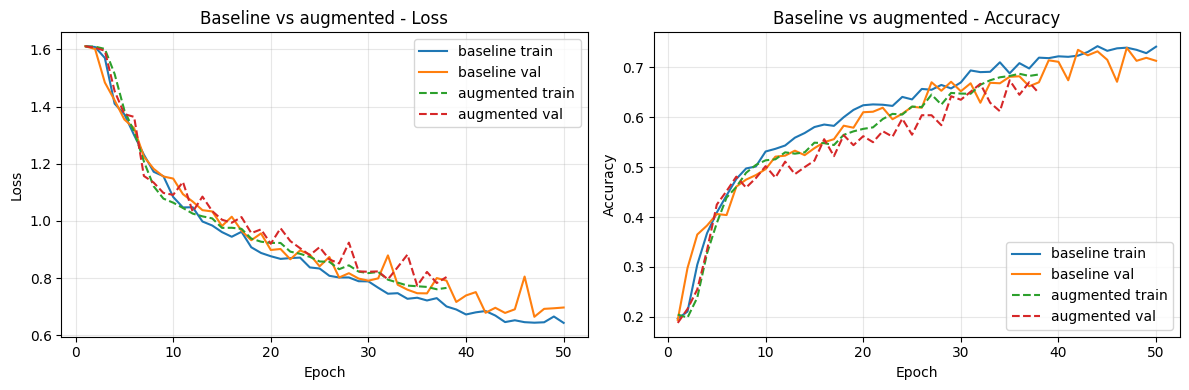

Seed=42 | Policy=baseline RGB    | Reward=16.61 | Length=1001
Seed=42 | Policy=augmented RGB   | Reward=16.61 | Length=1001
Seed=43 | Policy=baseline RGB    | Reward=-43.89 | Length=1001
Seed=43 | Policy=augmented RGB   | Reward=348.84 | Length=1001
Seed=44 | Policy=baseline RGB    | Reward=126.36 | Length=1001
Seed=44 | Policy=augmented RGB   | Reward=258.17 | Length=1001


In [13]:
# TODO: collect your final numbers in a table
plot_experiment_comparison(baseline_history, augmented_history, "baseline", "augmented", "Baseline vs augmented")
for r in all_results:
    print(
        f"Seed={r['seed']} | Policy={r['policy']:<15} | "
        f"Reward={r['reward']:.2f} | Length={r['episode_length']}"
    )


# TODO: add your written discussion in a markdown cell below

### Discussion

**Answer:** 

4.
In numbers, the best model is the baseline model. It has better accuracy + lower loss after training and better scores + better numbers in the confusion matrix as the augmented model. This can be explained by looking at the augmentations done to the images. The augmentations could be too harsh for the purpose. Especially flipping or tilting the image is an augmentation which could harm the trainingsprogress instead of reinforcing the model. 
But in the simulation, the best model is the augmented model. It is able to drive longer in the environment and shows good driving capabilities for less trained epochs than the baseline model. The results could be different after dealing the issue with the action class break, but for now these are the results.

5.
About class imbalance, this isn't an issue in my case since my dataset is equally distributed for all actions. But normally when gathering the dataset there is a huge imbalance of the actions taken in the simulator. Normally I either accelerate or do nothing when driving but never break. But in order to get some breaking data I chose to gather data until I match the amount of the other actions. Maybe I could improve my model by adding a slight imbalance of action classes (e.g. Less breaking data but more do nothing), but the normal action distribution is an issue for the model training. Other problems I already mentioned in task 5 & 6. 

6.
As I mentioned in 4. the augmentations done to the dataset are quite harsh for their purpose. That's why the augmented model is in numbers inferior to the baseline model. However the driving capabilities of the augmented model in the simulator are much better than the baseline model. 


